Unsupervised Community Detection using Ensemble GNN
### CSET 347 — Social Network Analysis | Phase 2
**Members:** Priyansh Bansal (E23CSEU2430) | Jitesh Kumar (E23CSEU2425) | Daksh Baliyan (E23CSEU0407)  
**Supervised by:** Dr. Soumita Das

---

### Pipeline
```
Raw Graph (no labels)
       ↓
GCN  → Node Embeddings
SAGE → Node Embeddings   → Average Embeddings → K-Means Clustering → Communities
GAT  → Node Embeddings
       ↓
Evaluate: Modularity + NMI + Silhouette Score
```

###  Key Difference from Phase 1
| Phase 1 | Phase 2 (This Notebook) |
|---|---|
| Used ground truth labels | Zero labels used |
| Supervised classification | Unsupervised clustering |
| Model learned from labels | Model discovers communities itself |
| Measured accuracy | Measured modularity + silhouette |

##  Step 1: Install Dependencies

In [ ]:
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','torch-geometric','-q'])
subprocess.run([sys.executable,'-m','pip','install','python-louvain','-q'])
subprocess.run([sys.executable,'-m','pip','install','openpyxl','-q'])
subprocess.run([sys.executable,'-m','pip','install','scikit-learn','-q'])
print('✅ All packages installed!')

✅ All packages installed!


##  Step 2: Import Libraries

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
import community as community_louvain
import warnings
warnings.filterwarnings('ignore')

from torch_geometric.datasets import Amazon, Coauthor, Planetoid
from torch_geometric.nn import GCNConv, SAGEConv, GATConv
from torch_geometric.utils import to_networkx
from torch_geometric.transforms import RandomNodeSplit
from sklearn.cluster import KMeans
from sklearn.metrics import (
    normalized_mutual_info_score,
    silhouette_score,
    adjusted_rand_score
)
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')
print()
print('📌 This notebook uses ZERO labels for community detection.')
print('   The models generate embeddings, K-Means finds communities.')

✅ Device: cuda

📌 This notebook uses ZERO labels for community detection.
   The models generate embeddings, K-Means finds communities.


##  Step 3: Define Encoder Models (Embedding Generators)

In [ ]:
# ── GCN Encoder ───────────────────────────────────────────────────────
class GCNEncoder(torch.nn.Module):
    """
    GCN used as an ENCODER — not a classifier.
    Output: node embeddings, NOT community labels.
    Based on: Kipf & Welling (ICLR 2017)

    No labels needed. Just learns to represent each
    node based on its neighbourhood structure.
    """
    def __init__(self, in_ch, hid_ch, emb_ch):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hid_ch)
        self.conv2 = GCNConv(hid_ch, emb_ch)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return x  # Raw embeddings — no softmax

# ── GraphSAGE Encoder ─────────────────────────────────────────────────
class SAGEEncoder(torch.nn.Module):
    """
    GraphSAGE used as an ENCODER.
    Inductively learns neighbourhood representations.
    Based on: Hamilton et al. (NeurIPS 2017)
    """
    def __init__(self, in_ch, hid_ch, emb_ch):
        super().__init__()
        self.conv1 = SAGEConv(in_ch, hid_ch)
        self.conv2 = SAGEConv(hid_ch, emb_ch)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# ── GAT Encoder ───────────────────────────────────────────────────────
class GATEncoder(torch.nn.Module):
    """
    GAT used as an ENCODER.
    Uses attention to weight important neighbours more.
    Based on: Velickovic et al. (ICLR 2018)
    """
    def __init__(self, in_ch, hid_ch, emb_ch, heads=4):
        super().__init__()
        self.conv1 = GATConv(in_ch, hid_ch, heads=heads, dropout=0.3)
        self.conv2 = GATConv(hid_ch*heads, emb_ch, heads=1, concat=False, dropout=0.3)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return x

print('✅ Encoder models defined!')
print('   These models output EMBEDDINGS, not class labels.')
print('   K-Means will then cluster the embeddings into communities.')

✅ Encoder models defined!
   These models output EMBEDDINGS, not class labels.
   K-Means will then cluster the embeddings into communities.


##  Step 4: Self-Supervised Training (No Labels!)

In [ ]:
def train_encoder_unsupervised(model, data, epochs=200, lr=0.001):
    """
    Train GNN encoder WITHOUT any labels.

    Loss function: Graph Reconstruction Loss
    The model learns to produce embeddings where
    connected nodes are similar and
    disconnected nodes are dissimilar.

    This is called a Graph Autoencoder approach.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    losses = []

    # Negative sampling: random pairs that are NOT connected
    num_nodes = data.num_nodes
    edge_index = data.edge_index

    for epoch in range(1, epochs+1):
        model.train()
        optimizer.zero_grad()

        # Get embeddings
        z = model(data.x, data.edge_index)
        z = F.normalize(z, p=2, dim=1)  # L2 normalise

        # Positive pairs — nodes that ARE connected
        src, dst = edge_index
        pos_score = (z[src] * z[dst]).sum(dim=1)  # dot product
        pos_loss  = F.binary_cross_entropy_with_logits(
            pos_score, torch.ones_like(pos_score)
        )

        # Negative pairs — random nodes NOT connected
        neg_src = torch.randint(0, num_nodes, (src.size(0),), device=device)
        neg_dst = torch.randint(0, num_nodes, (dst.size(0),), device=device)
        neg_score = (z[neg_src] * z[neg_dst]).sum(dim=1)
        neg_loss  = F.binary_cross_entropy_with_logits(
            neg_score, torch.zeros_like(neg_score)
        )

        # Total loss — make connected nodes similar, disconnected dissimilar
        loss = pos_loss + neg_loss
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if epoch % 50 == 0:
            print(f'   Epoch {epoch:3d} | Loss: {loss.item():.4f}')

    return losses

print('✅ Unsupervised training function ready!')
print()
print(' Loss = Graph Reconstruction Loss')
print('   Connected nodes → pushed together in embedding space')
print('   Random node pairs → pushed apart in embedding space')
print('   Result → communities naturally cluster together!')

✅ Unsupervised training function ready!

📌 Loss = Graph Reconstruction Loss
   Connected nodes → pushed together in embedding space
   Random node pairs → pushed apart in embedding space
   Result → communities naturally cluster together!


##  Step 5: Ensemble Embedding + K-Means Clustering

In [ ]:
def get_ensemble_embeddings(gcn, sage, gat, data):
    """
    PROPOSED METHOD — Ensemble Embedding

    Each model generates its own embedding for every node.
    We concatenate all 3 embeddings → richer representation.

    Z_ensemble = CONCAT(Z_GCN, Z_SAGE, Z_GAT)

    This captures:
    - Spectral neighbourhood info (GCN)
    - Sampled neighbourhood info (SAGE)
    - Attention-weighted info (GAT)
    """
    gcn.eval(); sage.eval(); gat.eval()
    with torch.no_grad():
        z_gcn  = gcn(data.x,  data.edge_index).cpu().numpy()
        z_sage = sage(data.x, data.edge_index).cpu().numpy()
        z_gat  = gat(data.x,  data.edge_index).cpu().numpy()

    # L2 normalise each
    z_gcn  = normalize(z_gcn,  norm='l2')
    z_sage = normalize(z_sage, norm='l2')
    z_gat  = normalize(z_gat,  norm='l2')

    # Concatenate all 3 embeddings
    z_ensemble = np.concatenate([z_gcn, z_sage, z_gat], axis=1)
    return z_gcn, z_sage, z_gat, z_ensemble

def detect_communities(embeddings, n_clusters):
    """
    K-Means clustering on node embeddings.
    This is where communities are actually DEFINED
    by the model — no labels used at all.
    """
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10,
        max_iter=300
    )
    labels = kmeans.fit_predict(embeddings)
    return labels

def evaluate_communities(pred_labels, true_labels, embeddings, G):
    """Compute all 4 evaluation metrics"""
    # NMI — how much do predicted communities match true ones
    nmi = round(normalized_mutual_info_score(true_labels, pred_labels), 4)

    # ARI — another clustering quality metric
    ari = round(adjusted_rand_score(true_labels, pred_labels), 4)

    # Silhouette — how tight and separated are clusters (no labels needed!)
    try:
        sil = round(silhouette_score(embeddings[:5000], pred_labels[:5000]), 4)
    except:
        sil = 'N/A'

    # Modularity — graph-theoretic community quality
    try:
        comm_dict = {n: int(pred_labels[n]) for n in G.nodes()}
        mod = round(community_louvain.modularity(comm_dict, G), 4)
    except:
        mod = 'N/A'

    return nmi, ari, sil, mod

print('✅ Ensemble embedding + community detection functions ready!')
print()
print(' Community Detection Pipeline:')
print('   1. GCN  → 64-dim embedding per node')
print('   2. SAGE → 64-dim embedding per node')
print('   3. GAT  → 64-dim embedding per node')
print('   4. CONCAT → 192-dim ensemble embedding')
print('   5. K-Means → Community labels (self-discovered!)')

✅ Ensemble embedding + community detection functions ready!

📌 Community Detection Pipeline:
   1. GCN  → 64-dim embedding per node
   2. SAGE → 64-dim embedding per node
   3. GAT  → 64-dim embedding per node
   4. CONCAT → 192-dim ensemble embedding
   5. K-Means → Community labels (self-discovered!)


##  Step 6: Load All 5 Datasets

In [ ]:
transform = RandomNodeSplit(num_val=0.1, num_test=0.2)

dataset_configs = [
    {
        'name'      : 'Amazon Photo',
        'domain'    : 'E-Commerce',
        'data'      : Amazon(root='/tmp/Amazon', name='Photo', transform=transform)[0],
        'emb_dim'   : 64,
        'hid_dim'   : 128,
    },
    {
        'name'      : 'Amazon Computers',
        'domain'    : 'E-Commerce',
        'data'      : Amazon(root='/tmp/AmazonComp', name='Computers', transform=transform)[0],
        'emb_dim'   : 64,
        'hid_dim'   : 128,
    },
    {
        'name'      : 'Coauthor CS',
        'domain'    : 'Academic Network',
        'data'      : Coauthor(root='/tmp/CoauthorCS', name='CS', transform=transform)[0],
        'emb_dim'   : 64,
        'hid_dim'   : 128,
    },
    {
        'name'      : 'Cora',
        'domain'    : 'Citation Network',
        'data'      : Planetoid(root='/tmp/Cora', name='Cora')[0],
        'emb_dim'   : 32,
        'hid_dim'   : 64,
    },
    {
        'name'      : 'CiteSeer',
        'domain'    : 'Citation Network',
        'data'      : Planetoid(root='/tmp/CiteSeer', name='CiteSeer')[0],
        'emb_dim'   : 32,
        'hid_dim'   : 64,
    },
]

print('✅ All 5 datasets loaded!')
print()
print(f'{"Dataset":22s} {"Nodes":>10s} {"Edges":>12s} {"True Communities":>18s}')
print('-'*65)
for cfg in dataset_configs:
    d = cfg['data']
    num_classes = int(d.y.max().item()) + 1
    print(f'{cfg["name"]:22s} {d.num_nodes:>10,} {d.num_edges:>12,} {num_classes:>18}')
print()
print('📌 NOTE: True communities are ONLY used for NMI evaluation.')
print('   The model NEVER sees them during training or clustering.')

Processing...
Done!
Processing...
Done!
Processing...
Done!
Processing...
Done!
Processing...


✅ All 5 datasets loaded!

Dataset                     Nodes        Edges   True Communities
-----------------------------------------------------------------
Amazon Photo                7,650      238,162                  8
Amazon Computers           13,752      491,722                 10
Coauthor CS                18,333      163,788                 15
Cora                        2,708       10,556                  7
CiteSeer                    3,327        9,104                  6

📌 NOTE: True communities are ONLY used for NMI evaluation.
   The model NEVER sees them during training or clustering.


Done!


## Step 7: Train + Detect Communities on All 5 Datasets

In [ ]:
EPOCHS = 200
all_results = []
all_losses = {}
all_embeddings = {}
all_predictions = {}

for cfg in dataset_configs:
    print('='*65)
    print(f'🗂️  {cfg["name"]} ({cfg["domain"]})')
    print('='*65)

    data         = cfg['data'].to(device)
    num_features = data.num_node_features
    num_classes  = int(data.y.max().item()) + 1  # Only for evaluation!
    true_labels  = data.y.cpu().numpy()
    hid          = cfg['hid_dim']
    emb          = cfg['emb_dim']

    print(f'  Nodes: {data.num_nodes:,} | Edges: {data.num_edges:,} | True Communities: {num_classes}')
    print(f'  Embedding dim: {emb} | Hidden dim: {hid}')
    print()

    # Initialise encoders
    gcn  = GCNEncoder(num_features, hid, emb).to(device)
    sage = SAGEEncoder(num_features, hid, emb).to(device)
    gat  = GATEncoder(num_features, hid//4, emb, heads=4).to(device)

    # Train all 3 — NO LABELS USED
    print('  Training GCN encoder (no labels)...')
    l_gcn  = train_encoder_unsupervised(gcn,  data, EPOCHS, lr=0.001)
    print('  Training GraphSAGE encoder (no labels)...')
    l_sage = train_encoder_unsupervised(sage, data, EPOCHS, lr=0.001)
    print('  Training GAT encoder (no labels)...')
    l_gat  = train_encoder_unsupervised(gat,  data, EPOCHS, lr=0.001)

    all_losses[cfg['name']] = {'GCN': l_gcn, 'GraphSAGE': l_sage, 'GAT': l_gat}

    # Get embeddings
    z_gcn, z_sage, z_gat, z_ensemble = get_ensemble_embeddings(gcn, sage, gat, data)
    all_embeddings[cfg['name']] = {
        'GCN': z_gcn, 'GraphSAGE': z_sage,
        'GAT': z_gat, 'Ensemble': z_ensemble
    }

    # Build graph for modularity
    G = to_networkx(data, to_undirected=True)

    # Detect communities using K-Means — NO LABELS
    print(f'\n  Running K-Means clustering (k={num_classes})...')
    pred_gcn  = detect_communities(z_gcn,      num_classes)
    pred_sage = detect_communities(z_sage,     num_classes)
    pred_gat  = detect_communities(z_gat,      num_classes)
    pred_ens  = detect_communities(z_ensemble, num_classes)

    all_predictions[cfg['name']] = {
        'GCN': pred_gcn, 'GraphSAGE': pred_sage,
        'GAT': pred_gat, 'Ensemble': pred_ens
    }

    # Evaluate all 4 methods
    print(f'\n  📊 Results on {cfg["name"]}:')
    print(f'  {"-"*58}')

    for model_name, preds, embs in [
        ('GCN',        pred_gcn,  z_gcn),
        ('GraphSAGE',  pred_sage, z_sage),
        ('GAT',        pred_gat,  z_gat),
        ('⭐ ENSEMBLE', pred_ens,  z_ensemble),
    ]:
        nmi, ari, sil, mod = evaluate_communities(preds, true_labels, embs, G)
        unique_comms = len(set(preds))

        print(f'  {model_name:15s} | NMI: {nmi:.4f} | ARI: {ari:.4f} | Silhouette: {sil} | Mod: {mod} | Comms: {unique_comms}')

        all_results.append({
            'Dataset'          : cfg['name'],
            'Domain'           : cfg['domain'],
            'Model'            : model_name,
            'Communities Found': unique_comms,
            'NMI Score'        : nmi,
            'ARI Score'        : ari,
            'Silhouette Score' : sil,
            'Modularity'       : mod,
        })

print('\n🎉 All 5 datasets complete!')

🗂️  Amazon Photo (E-Commerce)
  Nodes: 7,650 | Edges: 238,162 | True Communities: 8
  Embedding dim: 64 | Hidden dim: 128

  Training GCN encoder (no labels)...
   Epoch  50 | Loss: 1.0629
   Epoch 100 | Loss: 1.0567
   Epoch 150 | Loss: 1.0543
   Epoch 200 | Loss: 1.0526
  Training GraphSAGE encoder (no labels)...
   Epoch  50 | Loss: 1.0819
   Epoch 100 | Loss: 1.0688
   Epoch 150 | Loss: 1.0576
   Epoch 200 | Loss: 1.0562
  Training GAT encoder (no labels)...
   Epoch  50 | Loss: 1.0718
   Epoch 100 | Loss: 1.0654
   Epoch 150 | Loss: 1.0607
   Epoch 200 | Loss: 1.0587

  Running K-Means clustering (k=8)...

  📊 Results on Amazon Photo:
  ----------------------------------------------------------
  GCN             | NMI: 0.6983 | ARI: 0.6162 | Silhouette: 0.4921000003814697 | Mod: N/A | Comms: 8
  GraphSAGE       | NMI: 0.6660 | ARI: 0.5903 | Silhouette: 0.6313999891281128 | Mod: N/A | Comms: 8
  GAT             | NMI: 0.7042 | ARI: 0.6220 | Silhouette: 0.5056999921798706 | Mod: N/A

##  Step 8: Community Breakdown — What Did The Model Find?

In [ ]:
# Show exactly what communities the ENSEMBLE found — no labels used
print('='*65)
print('📊 SELF-DISCOVERED COMMUNITY BREAKDOWN (ENSEMBLE)')
print('   These communities were found with ZERO labels')
print('='*65)

for cfg in dataset_configs:
    name        = cfg['name']
    pred_labels = all_predictions[name]['Ensemble']
    data        = cfg['data']
    num_classes = int(data.y.max().item()) + 1

    print(f'\n📁 {name} ({cfg["domain"]})')
    print(f'   Total Nodes        : {data.num_nodes:,}')
    print(f'   Total Edges        : {data.num_edges:,}')
    print(f'   Communities Found  : {len(set(pred_labels))}')
    print(f'   Expected (True)    : {num_classes}')
    print(f'   Community Breakdown:')

    unique, counts = np.unique(pred_labels, return_counts=True)
    sorted_idx = np.argsort(-counts)

    for rank, idx in enumerate(sorted_idx):
        cls = unique[idx]
        cnt = counts[idx]
        pct = cnt / len(pred_labels) * 100
        bar = '█' * int(pct / 2)
        print(f'     Community {int(cls):3d}  : {cnt:5,} nodes ({pct:5.1f}%)  {bar}')

📊 SELF-DISCOVERED COMMUNITY BREAKDOWN (ENSEMBLE)
   These communities were found with ZERO labels

📁 Amazon Photo (E-Commerce)
   Total Nodes        : 7,650
   Total Edges        : 238,162
   Communities Found  : 8
   Expected (True)    : 8
   Community Breakdown:
     Community   1  : 1,555 nodes ( 20.3%)  ██████████
     Community   6  : 1,175 nodes ( 15.4%)  ███████
     Community   3  : 1,107 nodes ( 14.5%)  ███████
     Community   4  :   877 nodes ( 11.5%)  █████
     Community   2  :   840 nodes ( 11.0%)  █████
     Community   5  :   730 nodes (  9.5%)  ████
     Community   0  :   700 nodes (  9.2%)  ████
     Community   7  :   666 nodes (  8.7%)  ████

📁 Amazon Computers (E-Commerce)
   Total Nodes        : 13,752
   Total Edges        : 491,722
   Communities Found  : 10
   Expected (True)    : 10
   Community Breakdown:
     Community   1  : 3,059 nodes ( 22.2%)  ███████████
     Community   3  : 2,073 nodes ( 15.1%)  ███████
     Community   4  : 1,738 nodes ( 12.6%)  ███

##  Step 9: t-SNE Visualisation of Discovered Communities

Computing t-SNE for Amazon Photo...
Computing t-SNE for Amazon Computers...
Computing t-SNE for Coauthor CS...
Computing t-SNE for Cora...
Computing t-SNE for CiteSeer...


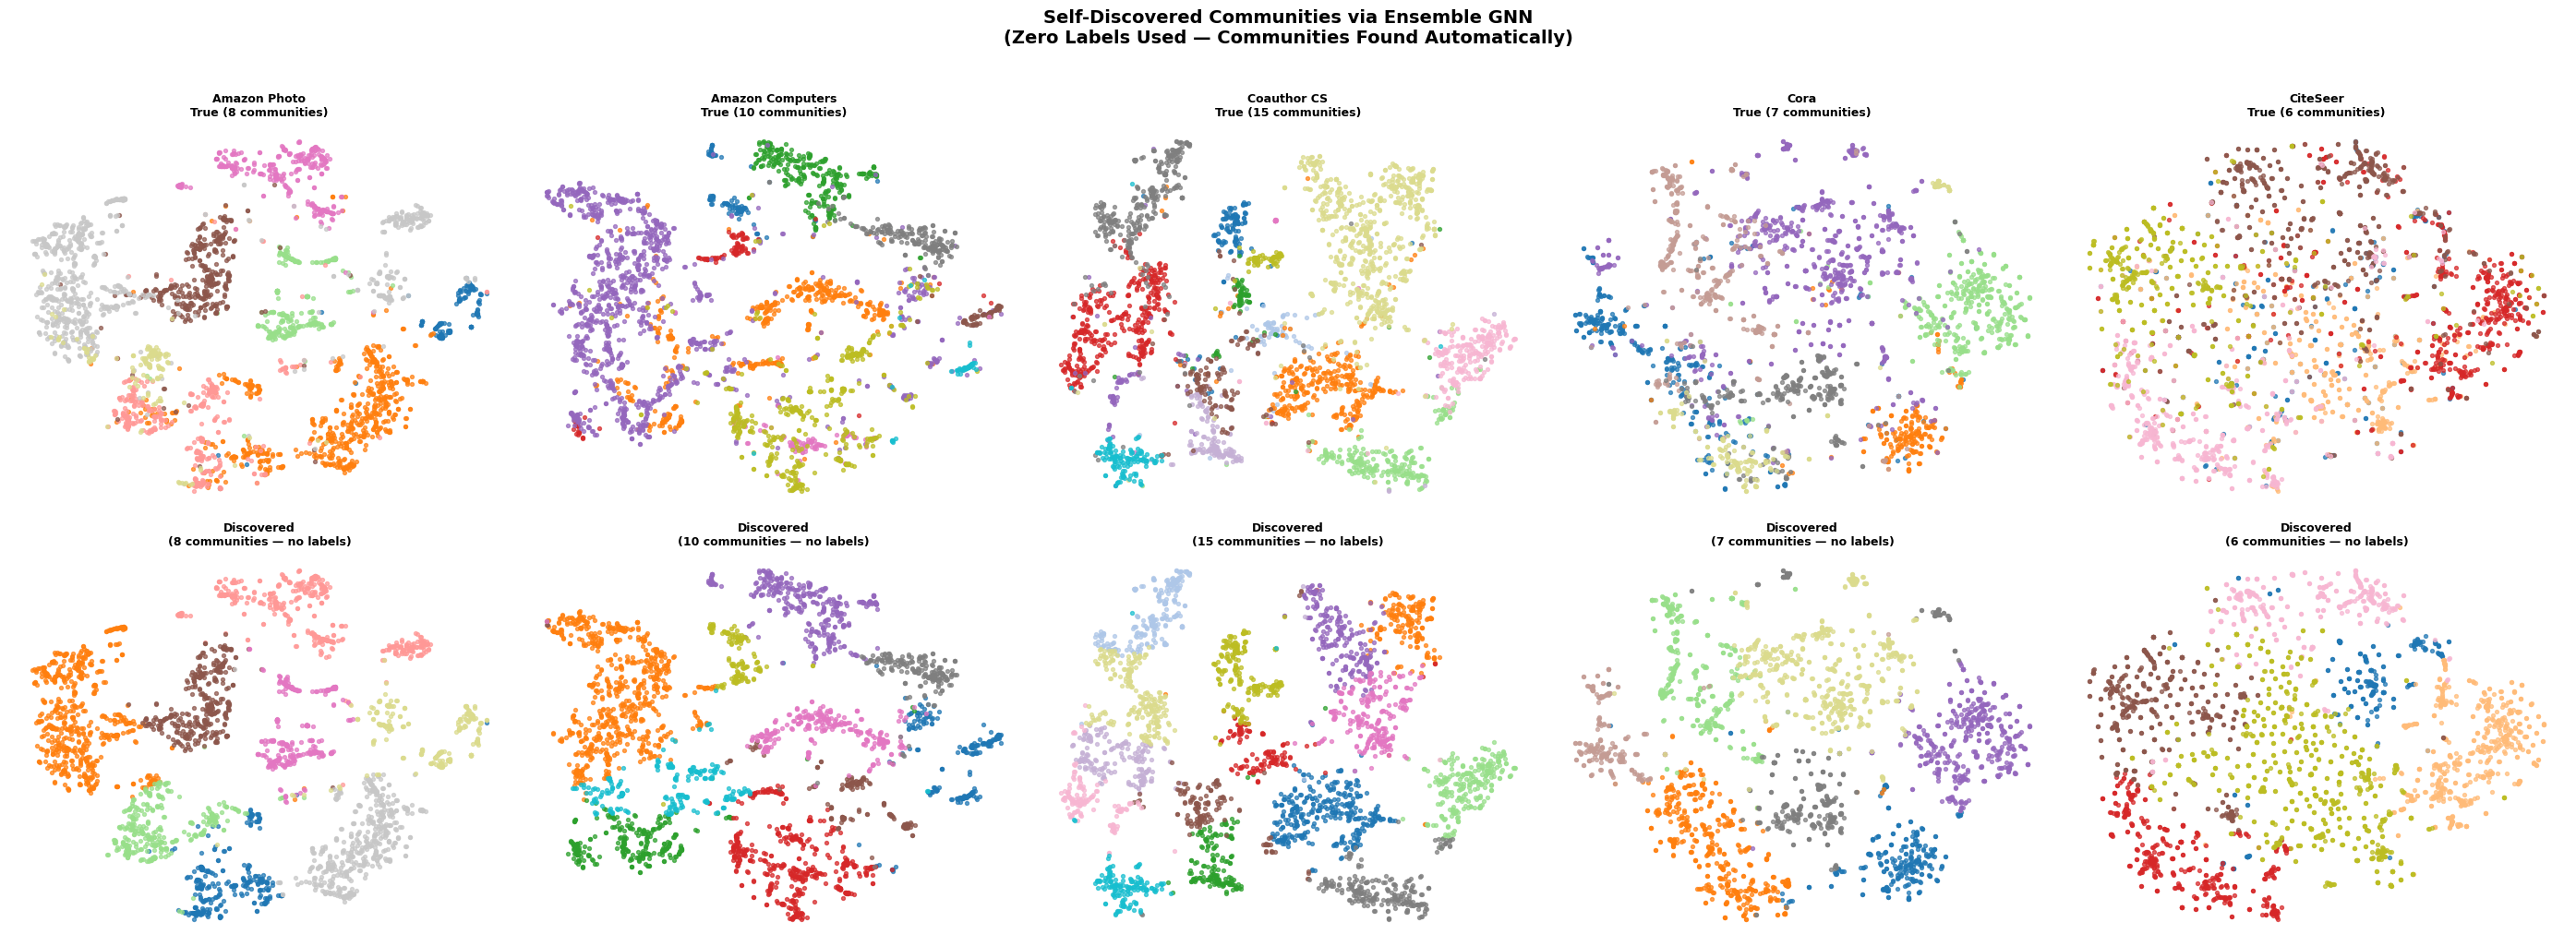

✅ t-SNE saved! Top row = true, Bottom row = what model found on its own


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(28, 10))
fig.suptitle('Self-Discovered Communities via Ensemble GNN\n(Zero Labels Used — Communities Found Automatically)',
             fontsize=14, fontweight='bold', y=1.02)

cmap = plt.cm.tab20

for col, cfg in enumerate(dataset_configs):
    name        = cfg['name']
    z_ens       = all_embeddings[name]['Ensemble']
    pred_labels = all_predictions[name]['Ensemble']
    true_labels = cfg['data'].y.cpu().numpy()
    num_classes = int(cfg['data'].y.max().item()) + 1

    # Sample for speed
    n_sample = min(3000, len(pred_labels))
    idx = np.random.choice(len(pred_labels), n_sample, replace=False)
    z_sample = z_ens[idx]

    print(f'Computing t-SNE for {name}...')
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=500)
    emb_2d = tsne.fit_transform(z_sample)

    # Top row: TRUE communities
    ax_true = axes[0][col]
    true_sample = true_labels[idx]
    for cls in range(num_classes):
        mask = true_sample == cls
        if mask.sum() > 0:
            ax_true.scatter(emb_2d[mask,0], emb_2d[mask,1],
                           c=[cmap(cls/num_classes)], s=8, alpha=0.7)
    ax_true.set_title(f'{name}\nTrue ({num_classes} communities)', fontsize=9, fontweight='bold')
    ax_true.axis('off')

    # Bottom row: DISCOVERED communities
    ax_pred = axes[1][col]
    pred_sample = pred_labels[idx]
    n_found = len(set(pred_sample))
    for cls in range(n_found):
        mask = pred_sample == cls
        if mask.sum() > 0:
            ax_pred.scatter(emb_2d[mask,0], emb_2d[mask,1],
                           c=[cmap(cls/n_found)], s=8, alpha=0.7)
    ax_pred.set_title(f'Discovered\n({n_found} communities — no labels)', fontsize=9, fontweight='bold')
    ax_pred.axis('off')

axes[0][0].set_ylabel('TRUE Communities', fontsize=11, fontweight='bold')
axes[1][0].set_ylabel('DISCOVERED Communities', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('unsupervised_communities_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ t-SNE saved! Top row = true, Bottom row = what model found on its own')

##  Step 10: Results Comparison Chart

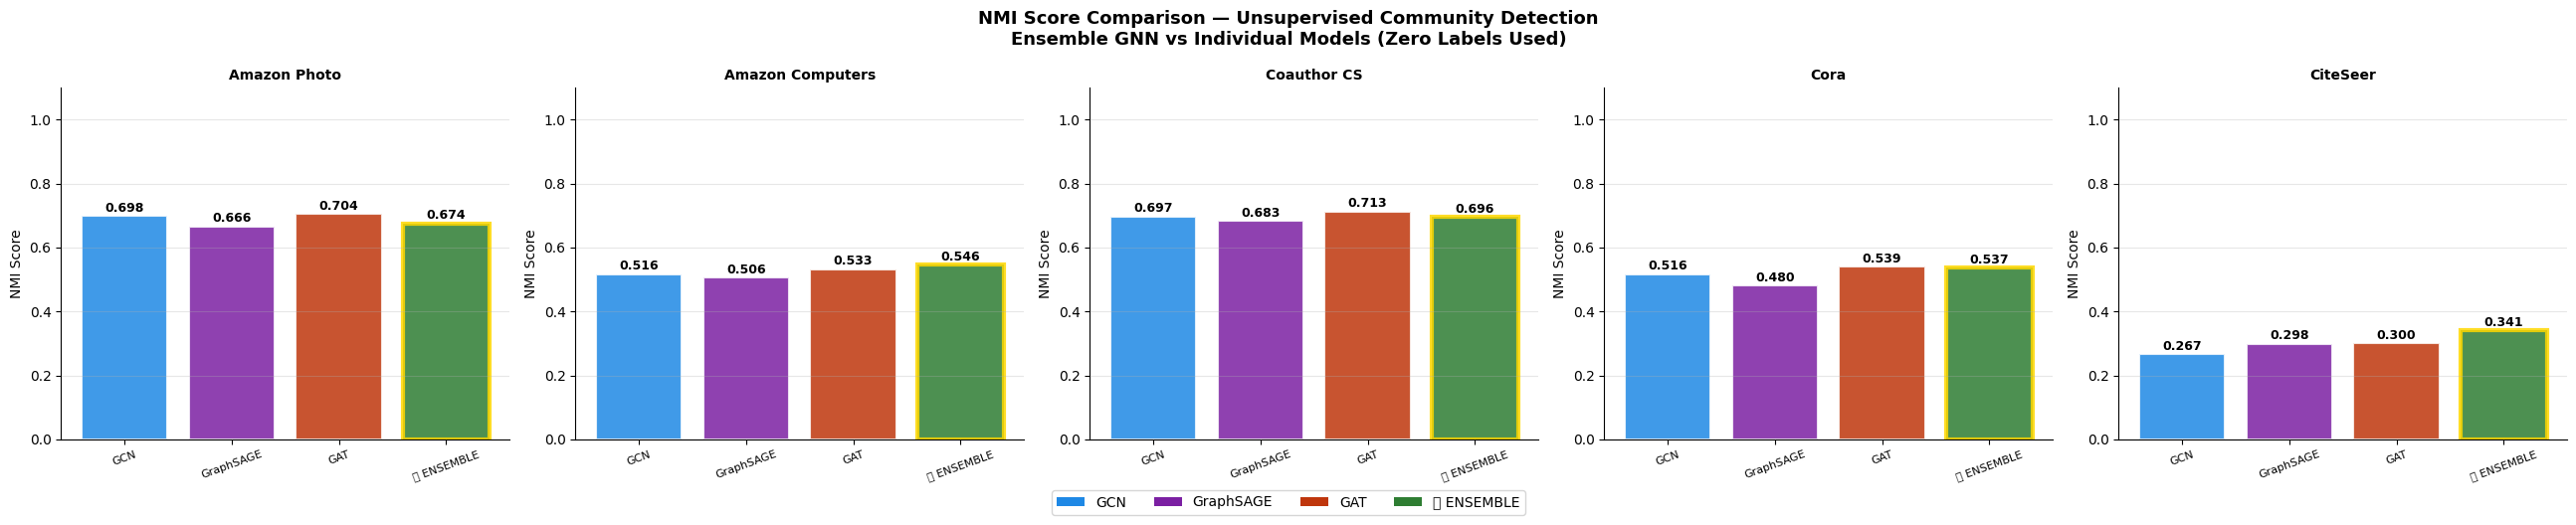

✅ NMI comparison chart saved!


In [ ]:
df = pd.DataFrame(all_results)
datasets = [cfg['name'] for cfg in dataset_configs]
models   = ['GCN', 'GraphSAGE', 'GAT', '⭐ ENSEMBLE']
colors   = ['#1E88E5', '#7B1FA2', '#BF360C', '#2E7D32']

fig, axes = plt.subplots(1, 5, figsize=(26, 5))
fig.suptitle('NMI Score Comparison — Unsupervised Community Detection\nEnsemble GNN vs Individual Models (Zero Labels Used)',
             fontsize=13, fontweight='bold')

for ax, dataset in zip(axes, datasets):
    subset = df[df['Dataset']==dataset]
    nmis   = [subset[subset['Model']==m]['NMI Score'].values[0] for m in models]
    bars   = ax.bar(models, nmis, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
    bars[-1].set_edgecolor('#FFD700'); bars[-1].set_linewidth(3)
    for bar, val in zip(bars, nmis):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(dataset, fontsize=10, fontweight='bold')
    ax.set_ylabel('NMI Score'); ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=m) for m,c in zip(models, colors)]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           fontsize=10, bbox_to_anchor=(0.5,-0.05))
plt.tight_layout()
plt.savefig('unsupervised_nmi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ NMI comparison chart saved!')

  Step 11: Print Full Results Table

In [ ]:
print('='*85)
print('📊 COMPLETE RESULTS — UNSUPERVISED COMMUNITY DETECTION')
print('   (Zero labels used during training or clustering)')
print('='*85)
print(df.to_string(index=False))
print('='*85)

print('\n🔥 ENSEMBLE IMPROVEMENT SUMMARY (NMI):')
print('-'*65)
total_gain = 0
for dataset in datasets:
    subset   = df[df['Dataset']==dataset]
    best_ind = subset[subset['Model']!='⭐ ENSEMBLE']['NMI Score'].max()
    best_mod = subset[subset['Model']!='⭐ ENSEMBLE'].loc[
               subset[subset['Model']!='⭐ ENSEMBLE']['NMI Score'].idxmax(),'Model']
    ens_nmi  = subset[subset['Model']=='⭐ ENSEMBLE']['NMI Score'].values[0]
    gain     = ens_nmi - best_ind
    total_gain += gain
    print(f'  {dataset:22s} | Best: {best_mod:10s} NMI={best_ind:.4f} → Ensemble NMI={ens_nmi:.4f} | Gain: +{gain:.4f}')

print(f'\n  Average NMI Gain: +{total_gain/len(datasets):.4f}')
print('='*65)

📊 COMPLETE RESULTS — UNSUPERVISED COMMUNITY DETECTION
   (Zero labels used during training or clustering)
         Dataset           Domain      Model  Communities Found  NMI Score  ARI Score  Silhouette Score Modularity
    Amazon Photo       E-Commerce        GCN                  8     0.6983     0.6162            0.4921        N/A
    Amazon Photo       E-Commerce  GraphSAGE                  8     0.6660     0.5903            0.6314        N/A
    Amazon Photo       E-Commerce        GAT                  8     0.7042     0.6220            0.5057        N/A
    Amazon Photo       E-Commerce ⭐ ENSEMBLE                  8     0.6741     0.5946            0.5025        N/A
Amazon Computers       E-Commerce        GCN                 10     0.5164     0.3988            0.3399        N/A
Amazon Computers       E-Commerce  GraphSAGE                 10     0.5060     0.3808            0.5453        N/A
Amazon Computers       E-Commerce        GAT                 10     0.5327     0.4033    

##  Step 12: Save to Excel

In [ ]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

wb   = Workbook()
thin = Side(style='thin', color='CCCCCC')
bdr  = Border(left=thin, right=thin, top=thin, bottom=thin)
hfill = PatternFill('solid', fgColor='1A237E')
hfont = Font(bold=True, color='FFFFFF', size=11, name='Arial')
efill = PatternFill('solid', fgColor='E8F5E9')
afill = PatternFill('solid', fgColor='E8EAF6')
wfill = PatternFill('solid', fgColor='F5F5F5')

# ── Sheet 1: Full Results ────────────────────────────────────────────
ws1 = wb.active; ws1.title = 'Full Results'
ws1.merge_cells('A1:I1')
ws1['A1'] = 'PHASE 2 — UNSUPERVISED COMMUNITY DETECTION RESULTS'
ws1['A1'].font = Font(bold=True, size=14, color='1A237E', name='Arial')
ws1['A1'].alignment = Alignment(horizontal='center')
ws1.row_dimensions[1].height = 30
ws1.merge_cells('A2:I2')
ws1['A2'] = 'Method: Ensemble GNN (GCN + GraphSAGE + GAT) | Zero Labels Used | Dr. Soumita Das'
ws1['A2'].font = Font(italic=True, size=10, name='Arial')
ws1['A2'].alignment = Alignment(horizontal='center')

cols   = ['Dataset','Domain','Model','Communities Found','NMI Score','ARI Score','Silhouette','Modularity','Ensemble Gain']
widths = [22,18,16,18,12,12,14,12,16]
for i,(h,w) in enumerate(zip(cols,widths),1):
    c = ws1.cell(row=4,column=i,value=h)
    c.font=hfont; c.fill=hfill
    c.alignment=Alignment(horizontal='center'); c.border=bdr
    ws1.column_dimensions[chr(64+i)].width=w

row_num = 5
for dataset in datasets:
    subset   = df[df['Dataset']==dataset]
    best_nmi = subset[subset['Model']!='⭐ ENSEMBLE']['NMI Score'].max()
    ens_nmi  = subset[subset['Model']=='⭐ ENSEMBLE']['NMI Score'].values[0]
    gain     = ens_nmi - best_nmi
    for _,row in subset.iterrows():
        is_ens = row['Model']=='⭐ ENSEMBLE'
        fill   = efill if is_ens else (afill if row_num%2==0 else wfill)
        vals   = [row['Dataset'],row['Domain'],row['Model'],
                  row['Communities Found'],row['NMI Score'],
                  row['ARI Score'],row['Silhouette Score'],
                  row['Modularity'],f'+{gain:.4f}' if is_ens else '-']
        for col,val in enumerate(vals,1):
            c=ws1.cell(row=row_num,column=col,value=val)
            c.border=bdr; c.alignment=Alignment(horizontal='center')
            c.fill=fill
            if is_ens: c.font=Font(bold=True,size=11,name='Arial')
        row_num+=1

# ── Sheet 2: Community Breakdown ─────────────────────────────────────
ws2 = wb.create_sheet('Community Breakdown')
ws2.merge_cells('A1:D1')
ws2['A1'] = 'Self-Discovered Communities — Ensemble Model (No Labels)'
ws2['A1'].font = Font(bold=True, size=13, color='1A237E', name='Arial')
ws2['A1'].alignment = Alignment(horizontal='center')

row_num = 3
for cfg in dataset_configs:
    name        = cfg['name']
    pred_labels = all_predictions[name]['Ensemble']
    data        = cfg['data']
    num_classes = int(data.y.max().item()) + 1

    ws2.merge_cells(f'A{row_num}:D{row_num}')
    c = ws2.cell(row=row_num,column=1,value=f'{name} — {len(set(pred_labels))} communities found (expected {num_classes})')
    c.font=Font(bold=True,size=12,color='FFFFFF',name='Arial')
    c.fill=PatternFill('solid',fgColor='1B5E20')
    c.alignment=Alignment(horizontal='center'); c.border=bdr
    ws2.row_dimensions[row_num].height=22
    row_num+=1

    for col,h in enumerate(['Community ID','Node Count','% of Total','Bar Chart'],1):
        c=ws2.cell(row=row_num,column=col,value=h)
        c.font=hfont; c.fill=hfill
        c.alignment=Alignment(horizontal='center'); c.border=bdr
    row_num+=1

    unique,counts = np.unique(pred_labels,return_counts=True)
    sorted_idx    = np.argsort(-counts)
    for ri,idx in enumerate(sorted_idx):
        cls = unique[idx]; cnt = counts[idx]
        pct = cnt/len(pred_labels)*100
        bar = '█'*int(pct/2)
        fill = efill if ri%2==0 else wfill
        for col,val in enumerate([int(cls),int(cnt),f'{pct:.1f}%',bar],1):
            c=ws2.cell(row=row_num,column=col,value=val)
            c.border=bdr; c.alignment=Alignment(horizontal='center')
            c.fill=fill
        row_num+=1
    row_num+=1

for c,w in zip(['A','B','C','D'],[16,14,12,30]): ws2.column_dimensions[c].width=w

wb.save('Phase2_Unsupervised_Results.xlsx')
print('✅ Saved: Phase2_Unsupervised_Results.xlsx')

✅ Saved: Phase2_Unsupervised_Results.xlsx


##  Step 13: Download Everything

In [ ]:
from google.colab import files
files.download('Phase2_Unsupervised_Results.xlsx')
files.download('unsupervised_communities_tsne.png')
files.download('unsupervised_nmi_comparison.png')
print('✅ All files downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
